In [1]:

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Train.csv")
cube = pd.pivot_table(
    df,
    values="Cost_of_the_Product",
    index="Warehouse_block",
    columns="Mode_of_Shipment",
    aggfunc="mean"
).round(2)

cube

Mode_of_Shipment,Flight,Road,Ship
Warehouse_block,,,
A,210.04,207.27,208.82
B,210.95,213.31,212.18
C,210.53,210.94,211.41
D,210.70,209.12,211.38
F,206.81,211.11,209.14


In [2]:
rollup = (
    df.groupby("Warehouse_block")["Cost_of_the_Product"]
      .mean()
      .round(2)
      .reset_index()
)

rollup

,Warehouse_block,Cost_of_the_Product
0,A,208.77
1,B,212.16
2,C,211.19
3,D,210.91
4,F,209.08


In [3]:

drilldown = (
    df.groupby(["Warehouse_block", "Product_importance"])
      ["Cost_of_the_Product"]
      .mean()
      .round(2)
      .reset_index()
)

drilldown
     

,Warehouse_block,Product_importance,Cost_of_the_Product
0,A,high,204.36
1,A,low,209.80
2,A,medium,208.49
3,B,high,199.39
4,B,low,214.41
5,B,medium,212.09
6,C,high,198.80
7,C,low,214.64
8,C,medium,210.02
9,D,high,212.22


In [4]:

slice_table = (
    df[df["Mode_of_Shipment"] == "Ship"]
      .groupby("Warehouse_block")["Cost_of_the_Product"]
      .mean()
      .round(2)
      .reset_index()
)

slice_table

,Warehouse_block,Cost_of_the_Product
0,A,208.82
1,B,212.18
2,C,211.41
3,D,211.38
4,F,209.14


In [5]:
dice_table = (
    df[
        (df["Mode_of_Shipment"].isin(["Ship", "Flight"])) &
        (df["Product_importance"] == "high") &
        (df["Customer_rating"] >= 4)
    ]
    .groupby(["Warehouse_block", "Mode_of_Shipment"])
    ["Cost_of_the_Product"]
    .mean()
    .round(2)
    .reset_index()
)

dice_table

,Warehouse_block,Mode_of_Shipment,Cost_of_the_Product
0,A,Flight,190.93
1,A,Ship,208.92
2,B,Flight,212.69
3,B,Ship,193.89
4,C,Flight,191.00
5,C,Ship,201.49
6,D,Flight,209.00
7,D,Ship,216.23
8,F,Flight,196.72
9,F,Ship,198.94


In [6]:

pivot = (
    pd.pivot_table(
        df,
        values="Reached.on.Time_Y.N",
        index="Mode_of_Shipment",
        columns="Product_importance",
        aggfunc="mean"
    )
    .mul(100)
    .round(2)
)

pivot
     

Product_importance,high,low,medium
Mode_of_Shipment,,,
Flight,58.28,59.90,60.82
Road,65.19,58.81,57.45
Ship,66.67,59.24,58.99


In [7]:
delivery_table = (
    df.groupby("Warehouse_block")["Reached.on.Time_Y.N"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

delivery_table

,Warehouse_block,Reached.on.Time_Y.N
0,A,58.65
1,B,60.23
2,C,59.68
3,D,59.76
4,F,59.85


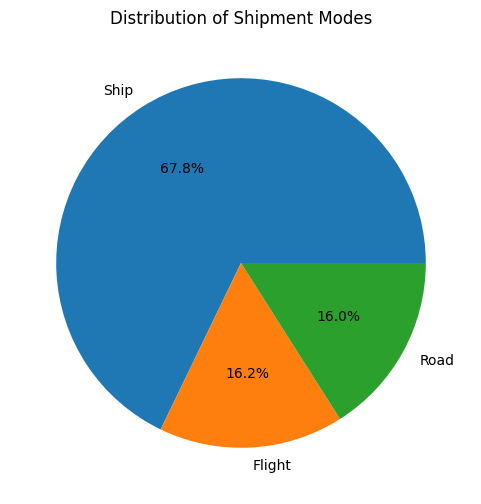

In [8]:
shipment_counts = df["Mode_of_Shipment"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    shipment_counts,
    labels=shipment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Distribution of Shipment Modes")
plt.show()